In [2]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# dataset_utils specific imports
from typing import Optional, List
from joblib import Parallel, delayed
from tqdm import tqdm 

In [3]:
from dataset_utls import find_edf_files, get_metadata_from_files, compute_metadata_statistics, create_stats_dataframe, compute_channel_stats, plot_channel_frequencies, preprocess_eeg, segment_eeg

In [4]:
DATA_PATH = '/Users/belial/Public/OneDrive - elte.hu/ELTE/Research_Projects/P2-Anomaly_detection/TUH_EEG_Corpus_v2.0.1/'

In [5]:
common_channels = sorted(
    [
        "EEG FP1-LE",
        "EEG FP2-LE",
        "EEG F3-LE",
        "EEG F4-LE",
        "EEG C3-LE",
        "EEG C4-LE",
        "EEG P3-LE",
        "EEG P4-LE",
        "EEG O1-LE",
        "EEG O2-LE",
        "EEG F7-LE",
        "EEG F8-LE",
        "EEG T3-LE",
        "EEG T4-LE",
        "EEG T5-LE",
        "EEG T6-LE",
        "EEG FZ-LE",
        "EEG CZ-LE",
        "EEG PZ-LE",
    ]
)
print(type(common_channels), len(common_channels))

<class 'list'> 19


In [6]:
# extract metadata from the files
edf_files_normal, _, _ = find_edf_files(DATA_PATH, montage='_le', epilepsy=False)
edf_files_abnormal, _, _ = find_edf_files(DATA_PATH, montage='_le', epilepsy=True)
normal_metadata_list = get_metadata_from_files(edf_files_normal)
abnormal_metadata_list = get_metadata_from_files(edf_files_abnormal)

In [7]:
normal_sub =  mne.io.read_raw_edf(edf_files_normal[0], preload=True)
abnormal_sub =  mne.io.read_raw_edf(edf_files_abnormal[0], preload=True)

Extracting EDF parameters from /Users/belial/Public/OneDrive - elte.hu/ELTE/Research_Projects/P2-Anomaly_detection/TUH_EEG_Corpus_v2.0.1/01_no_epilepsy/aaaaamba/s001_2011/02_tcp_le/aaaaamba_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 345749  =      0.000 ...  1382.996 secs...
Extracting EDF parameters from /Users/belial/Public/OneDrive - elte.hu/ELTE/Research_Projects/P2-Anomaly_detection/TUH_EEG_Corpus_v2.0.1/00_epilepsy/aaaaabju/s001_2003/02_tcp_le/aaaaabju_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 277999  =      0.000 ...  1111.996 secs...


In [8]:
no_raw_ch = normal_sub.copy().pick(common_channels)
ab_raw_ch = abnormal_sub.copy().pick(common_channels)

In [15]:
ch = no_raw_ch.info['ch_names']
print(ch)

['EEG C3-LE', 'EEG C4-LE', 'EEG CZ-LE', 'EEG F3-LE', 'EEG F4-LE', 'EEG F7-LE', 'EEG F8-LE', 'EEG FP1-LE', 'EEG FP2-LE', 'EEG FZ-LE', 'EEG O1-LE', 'EEG O2-LE', 'EEG P3-LE', 'EEG P4-LE', 'EEG PZ-LE', 'EEG T3-LE', 'EEG T4-LE', 'EEG T5-LE', 'EEG T6-LE']


In [10]:
no_raw_data = no_raw_ch.get_data()
ab_raw_data = ab_raw_ch.get_data()

Using matplotlib as 2D backend.


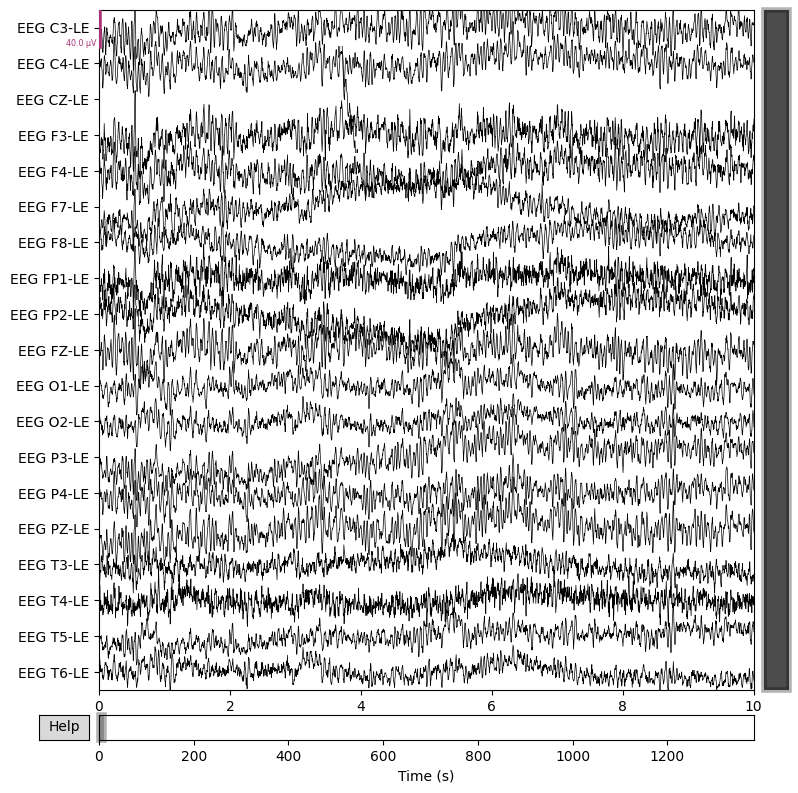

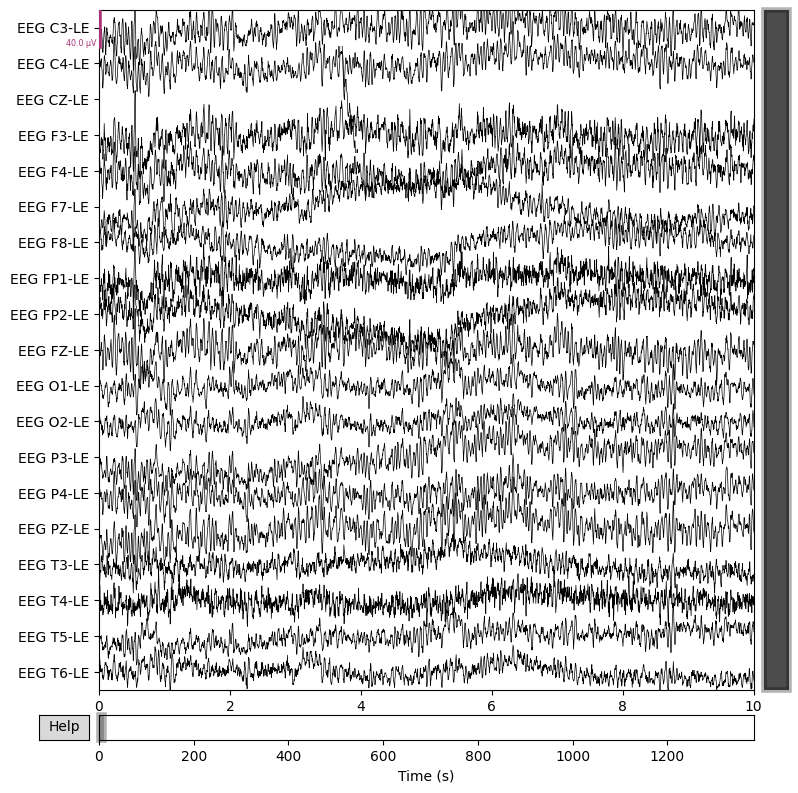

In [20]:
no_raw_ch.plot()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


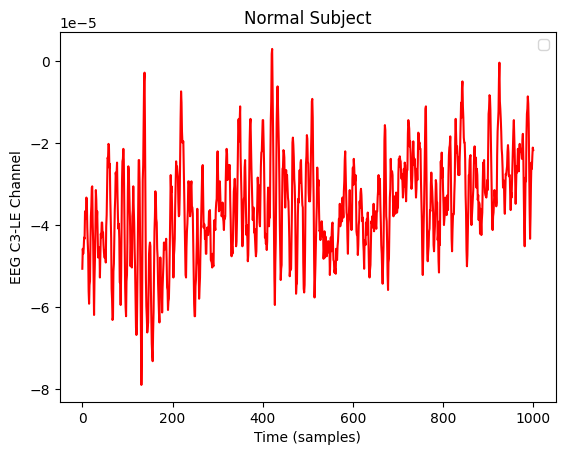

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


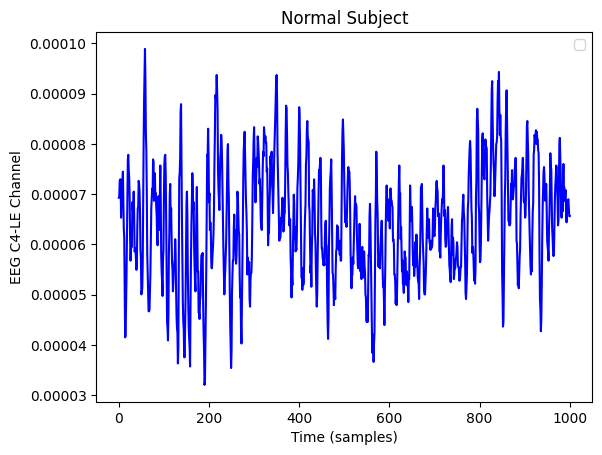

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


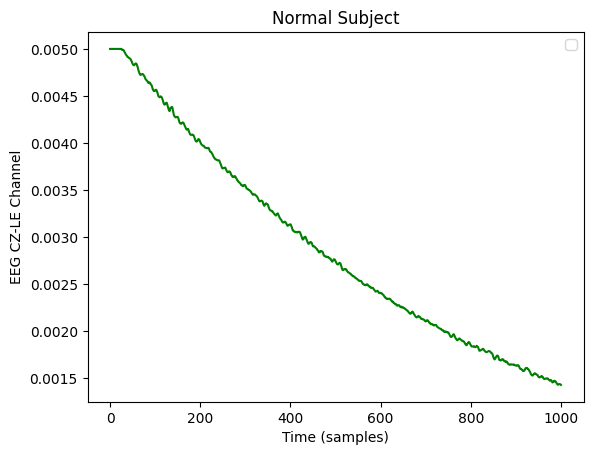

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


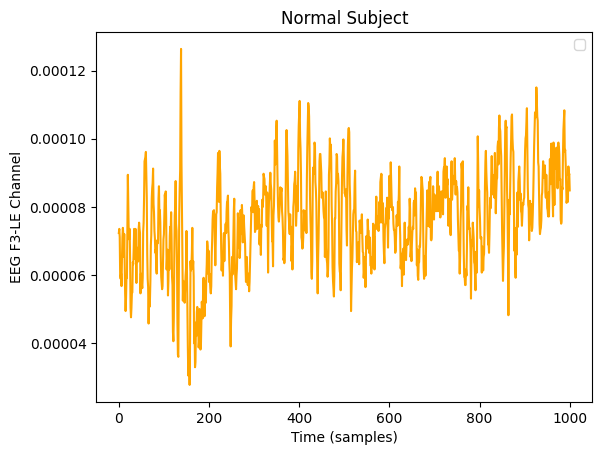

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


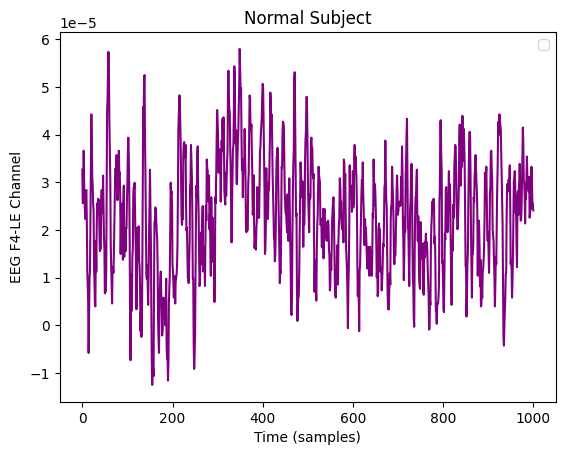

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


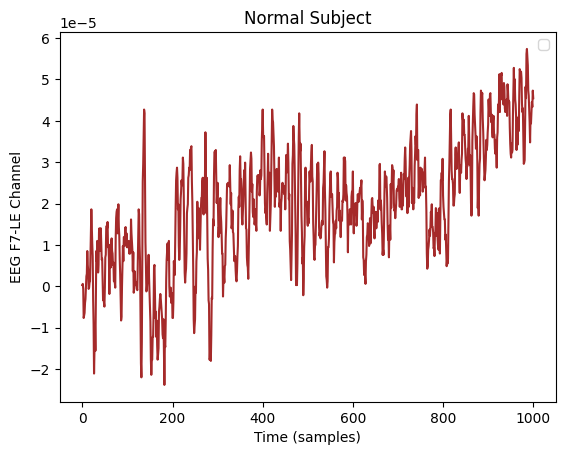

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


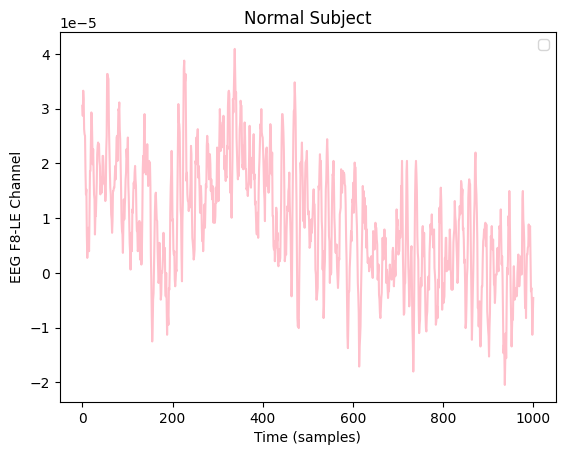

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


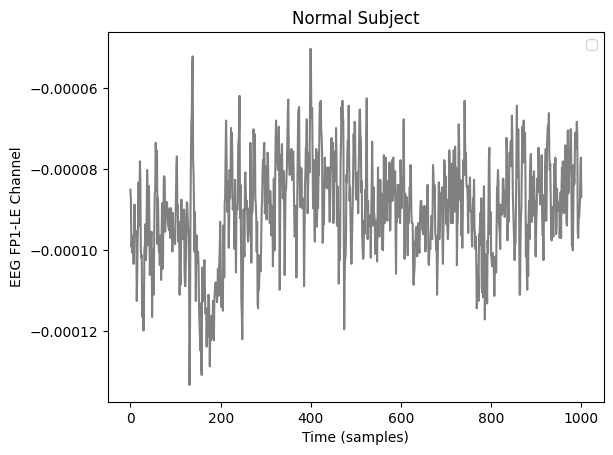

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


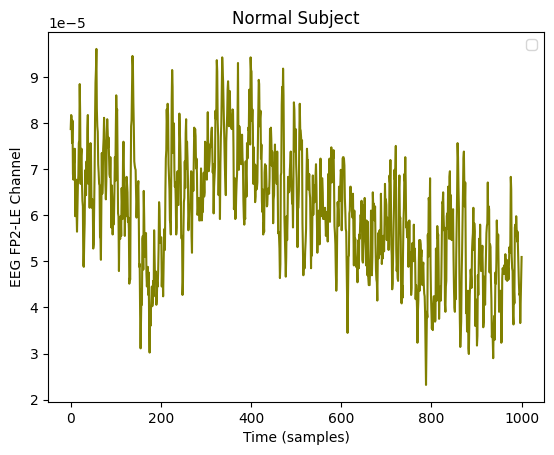

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


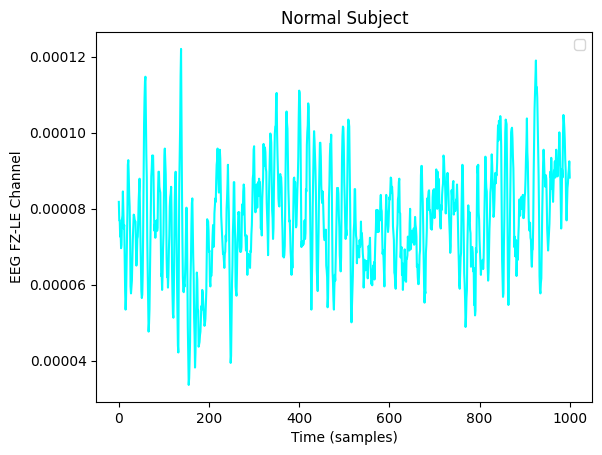

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


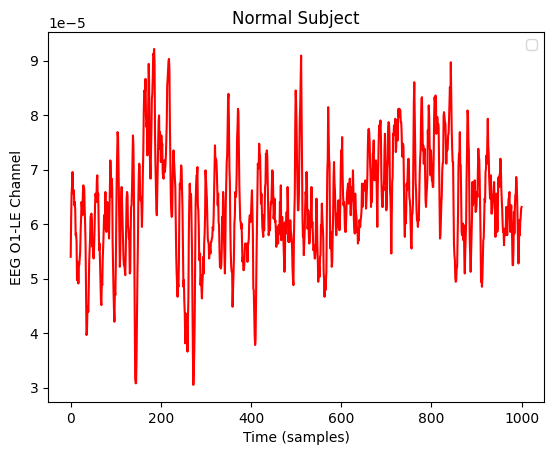

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


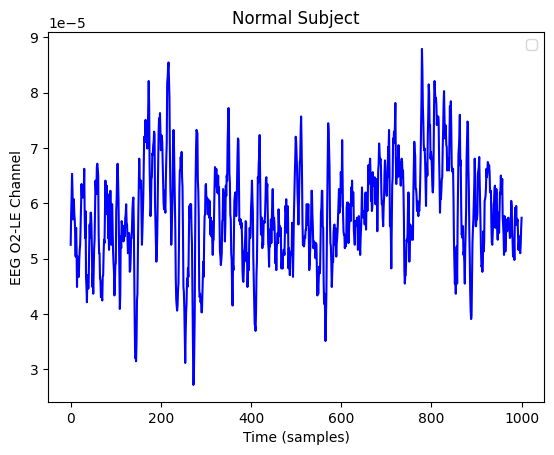

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


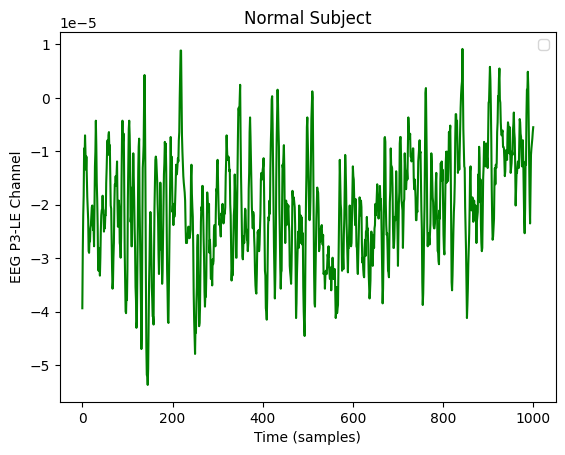

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


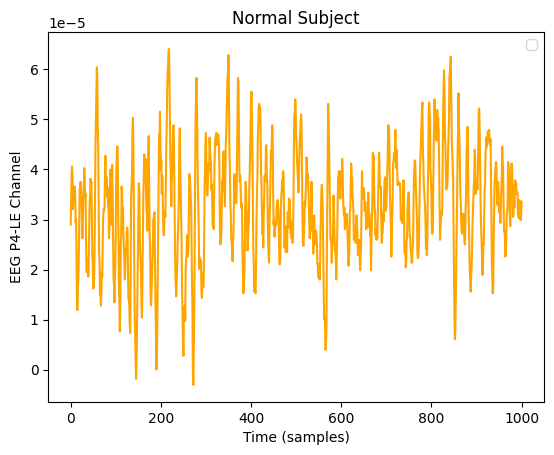

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


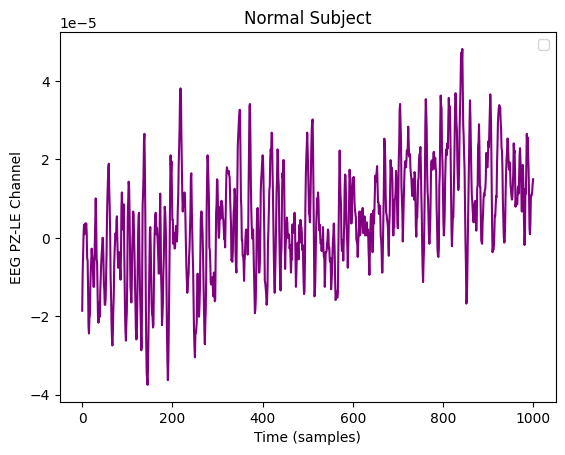

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


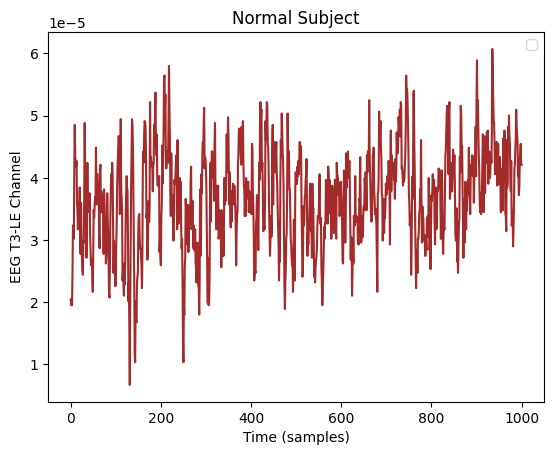

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


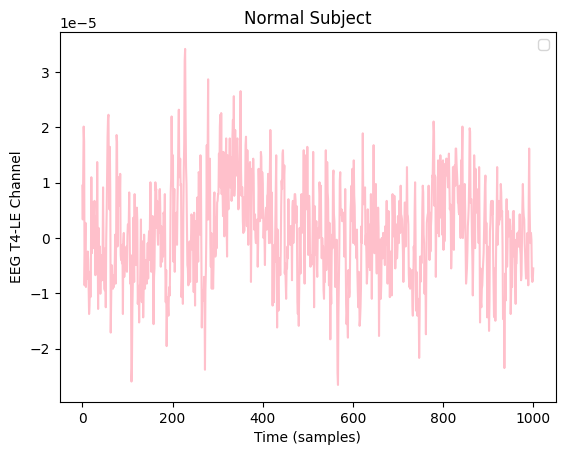

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


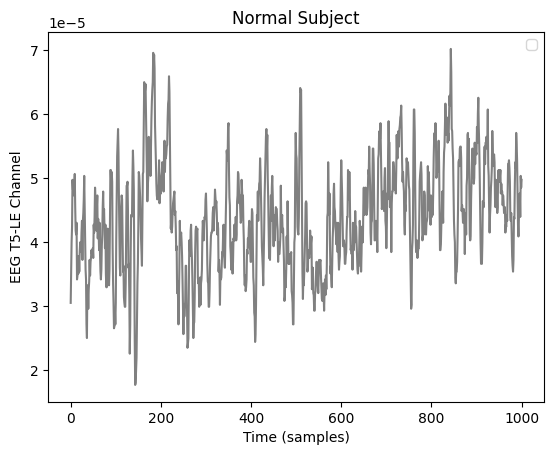

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


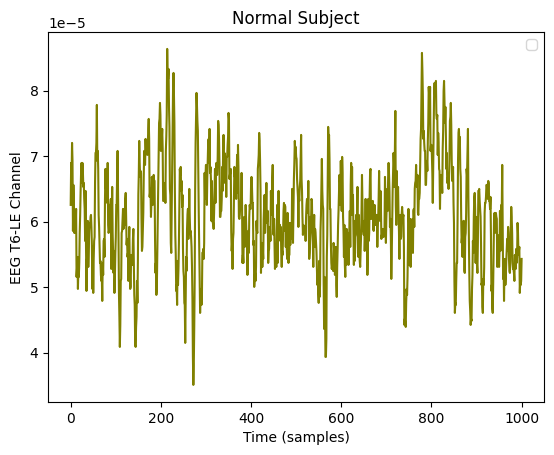

In [19]:
n_ch,  n_samples = no_raw_data.shape
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'] * 2
for i in range(n_ch):
    plt.plot(no_raw_data[i][:1001],color=colors[i])
    plt.title('Normal Subject')
    plt.xlabel('Time (samples)')
    plt.ylabel('{} Channel'.format(ch[i]))
    plt.legend()
    plt.show()


In [22]:
no_preprocessed = preprocess_eeg(edf_files_normal[0], common_channels)

In [24]:
no_segmented = segment_eeg(no_preprocessed, sfreq=250, window_sec=1, overlap=0.5)

In [26]:
no_segmented.shape

(2765, 19, 250)

/var/folders/gn/g0szlcgn2sq2ycrwdq8bmf5w0000gn/T/ipykernel_26994/2942150458.py:30: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, pad=0.01)


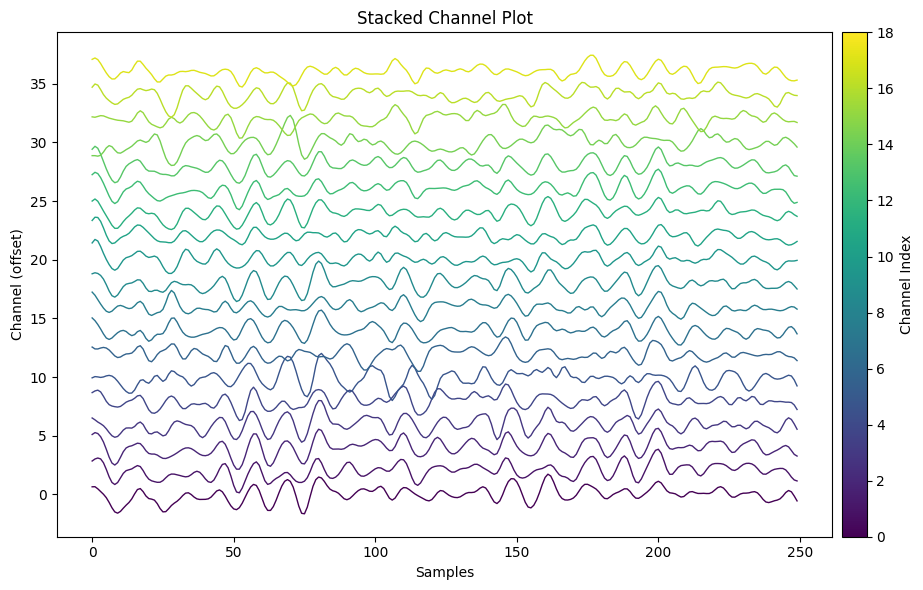

In [31]:


# Generate sample data (replace this with your actual data)
data = no_segmented[1700]  # 19 channels, 250 samples

# Create plot
plt.figure(figsize=(10, 6))

# Choose a colormap
cmap = plt.cm.viridis  # You can change this to any matplotlib colormap (e.g., 'plasma', 'rainbow')

# Calculate vertical offsets
vertical_spacing = 2.0  # Adjust this based on your data range
offsets = np.arange(data.shape[0]) * vertical_spacing

# Create x-axis values (sample numbers)
x = np.arange(data.shape[1])

# Plot each channel with different color
for i, (channel, offset) in enumerate(zip(data, offsets)):
    color = cmap(i / data.shape[0])  # Normalize index to [0,1] for colormap
    plt.plot(x, channel + offset, color=color, lw=1)

# Add labels and title
plt.xlabel("Samples")
plt.ylabel("Channel (offset)")
plt.title("Stacked Channel Plot")

# Optional: Add colorbar to show channel mapping
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=data.shape[0]-1))
sm.set_array([])
cbar = plt.colorbar(sm, pad=0.01)
cbar.set_label("Channel Index")

plt.tight_layout()
plt.show()

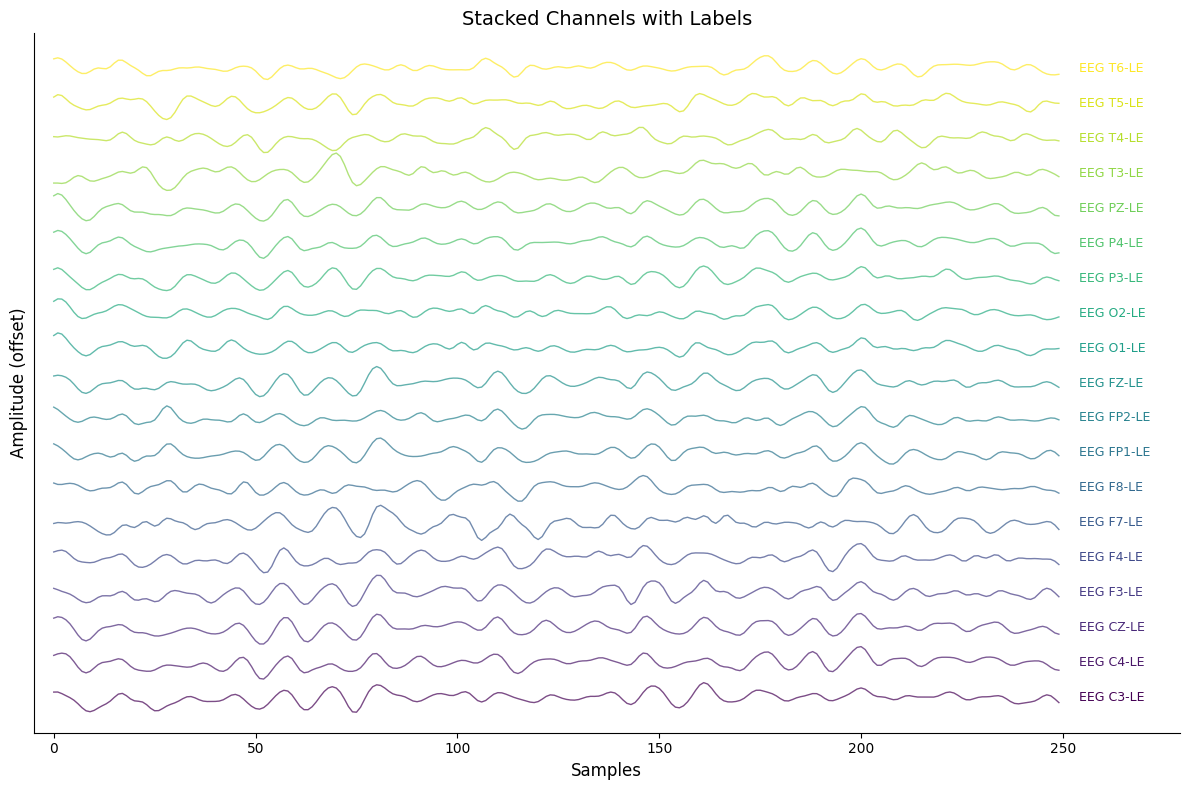

In [ ]:

channel_names = common_channels  # Your channel names here

# Create plot
plt.figure(figsize=(12, 8))

# Customize colors if desired (or keep default)
colors = plt.cm.viridis(np.linspace(0, 1, len(channel_names)))  # Optional color scheme

# Calculate vertical offsets
vertical_spacing = 4.0  # Increase spacing for better text visibility
offsets = np.arange(data.shape[0]) * vertical_spacing

x = np.arange(data.shape[1])

# Plot each channel with labels
for i, (channel, offset, name) in enumerate(zip(data, offsets, channel_names)):
    # Plot the line
    plt.plot(x, channel + offset, 
             color=colors[i], 
             lw=1,
             alpha=0.7)
    
    # Add channel name label at right end
    plt.text(x[-1] + 5,  # Position text slightly right of plot
             offset, 
             name, 
             ha='left', 
             va='center',
             fontsize=9,
             color=colors[i])

# Adjust plot limits to accommodate labels
plt.xlim(-5, x[-1] + 30)  # Add extra space on right for labels
plt.ylim(-vertical_spacing, offsets[-1] + vertical_spacing)

# Add labels and title
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.title("Stacked Channels with Labels", fontsize=14)

# Remove spines and ticks for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.yticks([])  # Remove y-axis ticks

plt.tight_layout()
plt.show()

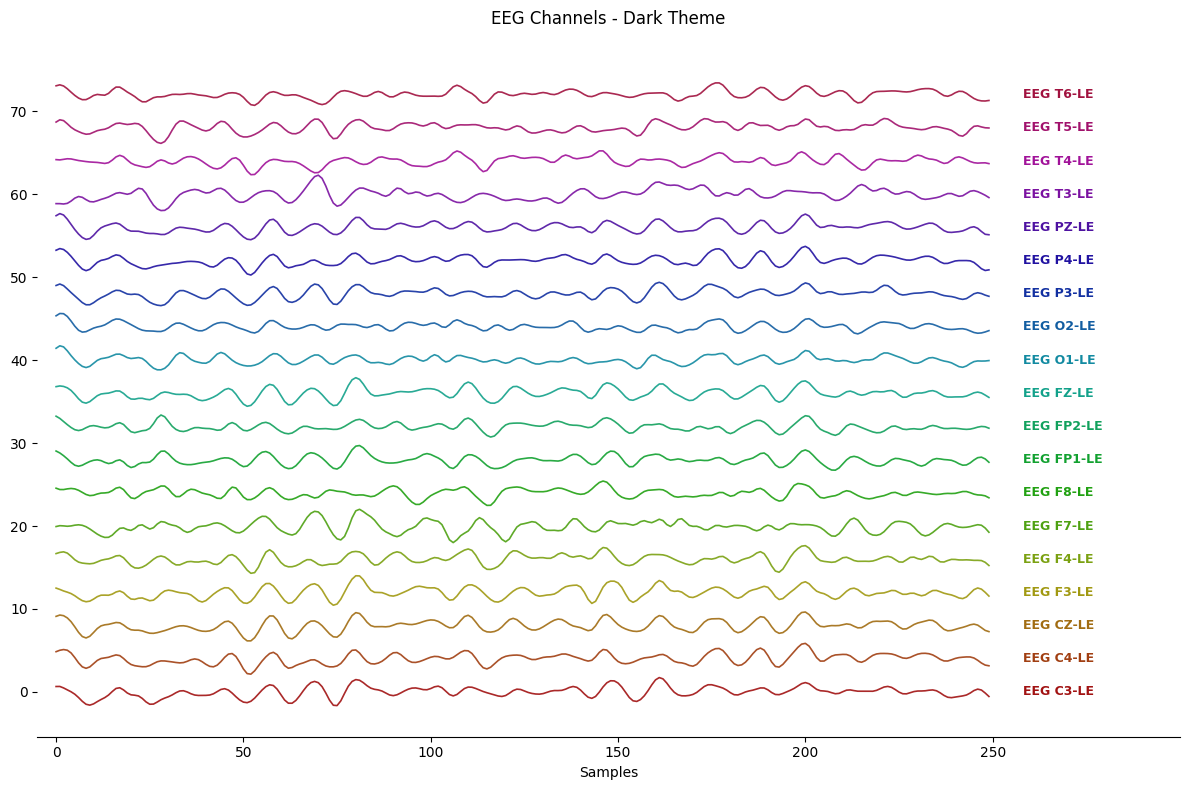

In [33]:

import colorsys

# Generate dark colors
def dark_colors(n, lightness=0.3, saturation=0.7):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [colorsys.hls_to_rgb(h, lightness, saturation) for h in hues]



# Setup plot
fig, ax = plt.subplots(figsize=(12, 8))
vertical_spacing = 4.0
offsets = np.arange(data.shape[0]) * vertical_spacing

# Generate dark colors
colors = dark_colors(len(channel_names), lightness=0.35, saturation=0.8)

# Plot channels
for i, (channel, offset, name) in enumerate(zip(data, offsets, channel_names)):
    ax.plot(channel + offset, 
            color=colors[i], 
            lw=1.2,
            alpha=0.9)
    ax.text(250 + 8, offset, name, 
            color=colors[i], 
            ha='left', 
            va='center',
            fontsize=9,
            fontweight='bold')

# Formatting
ax.set_xlim(-5, 250 + 50)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_xticks(np.arange(0, 251, 50))
ax.set_xlabel("Samples", fontsize=10)
ax.set_title("EEG Channels - Dark Theme", pad=20, fontsize=12)
plt.tight_layout()
plt.show()

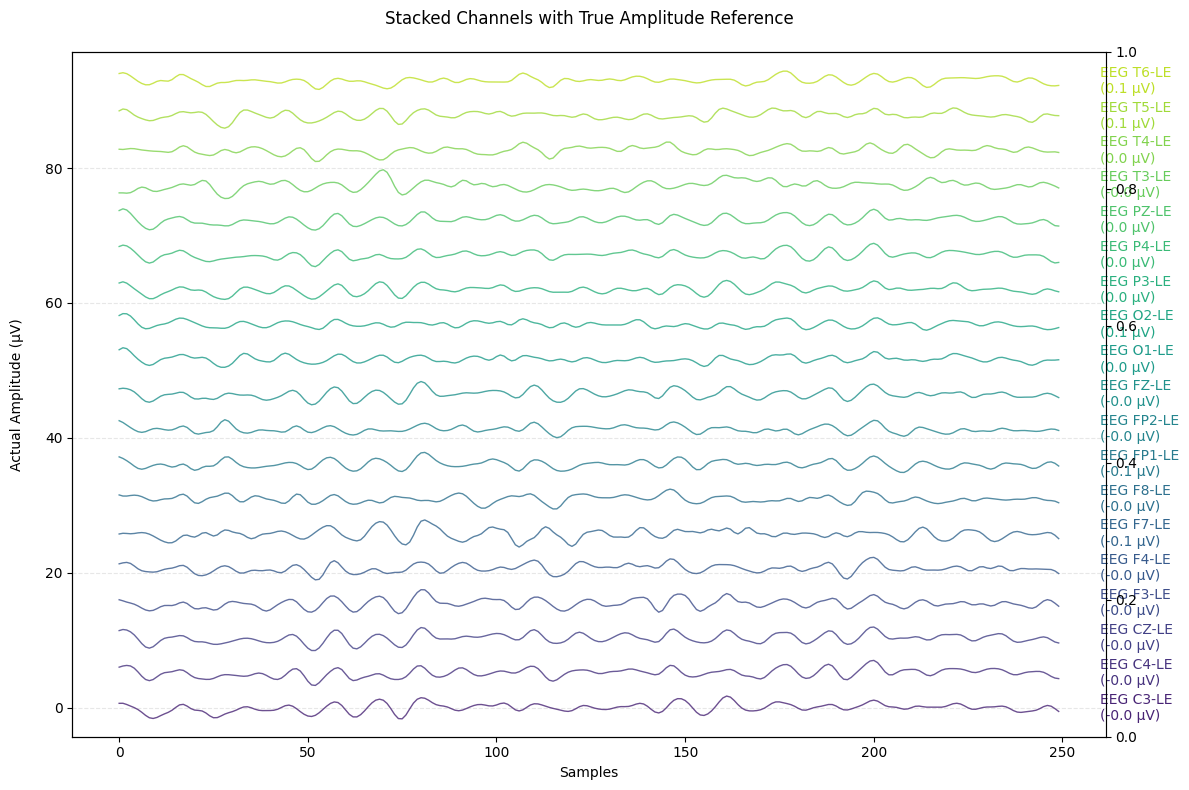

In [35]:


# Setup plot
fig, ax1 = plt.subplots(figsize=(12, 8))
ax2 = ax1.twinx()  # Create second y-axis for amplitude scale

# Color settings
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(channel_names)))

# Calculate offsets based on data range
data_range = np.ptp(data)
vertical_spacing = data_range * 1.2  # 20% spacing between channels
offsets = np.arange(len(channel_names)) * vertical_spacing

# Plot channels with actual amplitudes
for i, (channel, offset, color) in enumerate(zip(data, offsets, cmap)):
    ax1.plot(channel + offset, 
             color=color, 
             lw=1,
             alpha=0.8)
    
    # Add channel labels with actual amplitude reference
    ax1.text(data.shape[1] + 10, 
             offset, 
             f'{channel_names[i]}\n({np.mean(channel):.1f} μV)', 
             color=color,
             va='center',
             ha='left')

# Set up axes

# Add amplitude scale on right axis
ax1.set_ylim(offsets[0] - data_range, offsets[-1] + data_range)
ax1.set_ylabel("Actual Amplitude (μV)", labelpad=15)
ax1.spines['right'].set_color('gray')

# Add grid for amplitude reference
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Other formatting
ax1.set_xlabel("Samples", fontsize=10)
ax1.set_title("Stacked Channels with True Amplitude Reference", pad=20)
plt.tight_layout()
plt.show()

Creating RawArray with float64 data, n_channels=19, n_times=250
    Range : 0 ... 249 =      0.000 ...     0.996 secs
Ready.
Effective window size : 1.000 (s)


/var/folders/gn/g0szlcgn2sq2ycrwdq8bmf5w0000gn/T/ipykernel_26994/1392424971.py:13: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = raw.compute_psd(fmin=0, fmax=49).plot(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


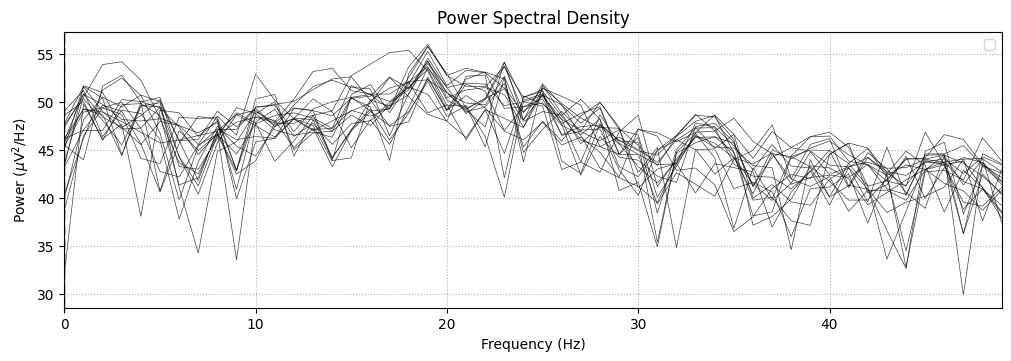

In [39]:
import numpy as np
import mne

# Sample data parameters (ADJUST THESE!)
sfreq = 250  # Sampling frequency (Hz)
ch_names = common_channels  # Channel names

# Create MNE Raw object from numpy array
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# Compute and plot PSD
fig = raw.compute_psd(fmin=0, fmax=49).plot(
    amplitude=True,  # Show μV²/Hz instead of dB
    average=False,   # Show individual channels
    picks='eeg',     # Only plot EEG channels
    xscale='linear', # Linear frequency axis
    show=False
)

# Customize plot
ax = fig.axes[0]
ax.set_title('Power Spectral Density')
ax.set_ylabel(r'Power ($\mu$V$^2$/Hz)')
ax.legend(loc='upper right')

plt.show()

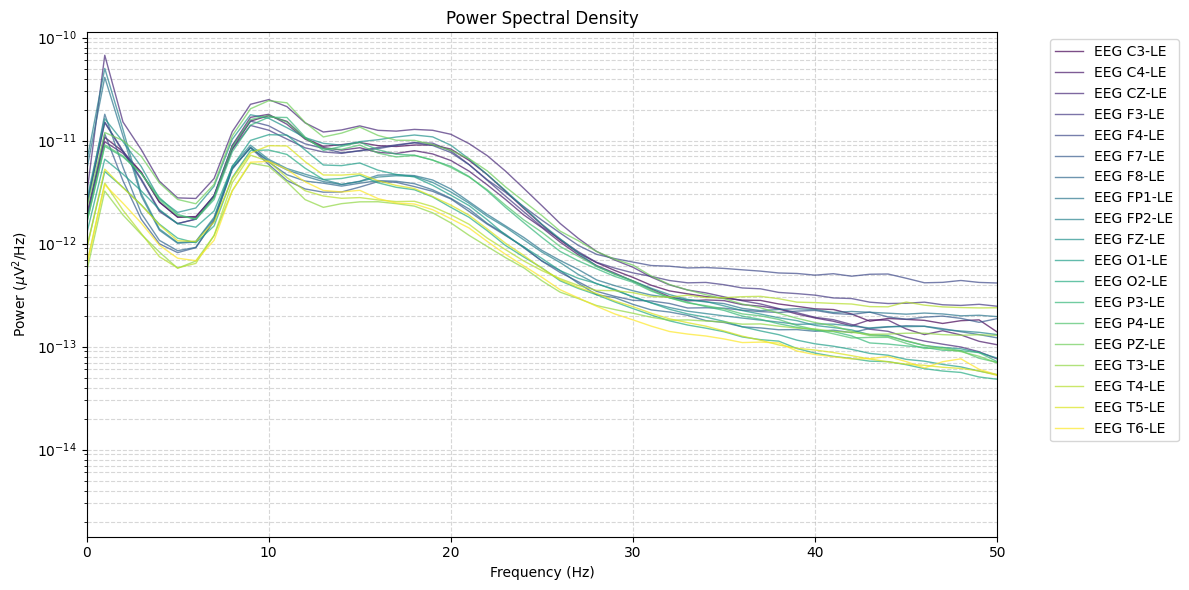

In [46]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# Generate sample data
data = no_raw_data

# Compute PSD
frequencies, psd = signal.welch(
    data,
    fs=sfreq,
    nperseg=sfreq*1,  # 2-second windows
    noverlap=sfreq*0.5,    # 50% overlap
    window='hann'
)

# Plot settings
cmap = plt.cm.viridis(np.linspace(0, 1, len(ch_names)))
plt.figure(figsize=(12, 6))

# Plot each channel
for i, (chan_psd, colors) in enumerate(zip(psd, cmap)):
    plt.plot(frequencies, chan_psd, 
             color=colors,
             label=ch_names[i],
             alpha=0.7,
             linewidth=1)

# Format plot
plt.xlim(0, 50)
#plt.ylim(1e-6, 1e-2)  # Adjust y-axis limits for better visibility
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Power ($\mu$V$^2$/Hz)')
plt.title('Power Spectral Density')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()